# Neural Style Transfer — Comparative Study
**Comparative Study of Deep Learning Approaches for Neural Style Transfer: Fast Feed-Forward Networks vs. Recent Arbitrary Style Transfer Methods**

---
### What this notebook does
1. Loads a content dataset (MS-COCO subset) and a style dataset (WikiArt subset).
2. **Trains** a Fast Neural Style Transfer network (Johnson et al., 2016) from scratch — this is the model required by the assignment.
3. Loads **two pretrained "existing/recent" methods** for comparison:
   - **AdaIN** (Huang & Belongie, ICCV 2017) — arbitrary style transfer via adaptive instance normalization.
   - **StyTr²** (Deng et al., CVPR 2022) — transformer-based arbitrary style transfer (recent SOTA).
4. Evaluates all three with **quantitative metrics**: content loss, style (Gram) loss, SSIM, LPIPS, and inference time.
5. Runs a small **ablation study** on the content/style loss weight ratio.

### Before you run this
Run the download scripts first (see `README.md`):
```bash
python scripts/download_coco.py
python scripts/download_wikiart.py
python scripts/download_pretrained_weights.py
```
This notebook assumes the folder layout created by those scripts (`data/coco/...`, `data/wikiart/...`, `models/adain/...`, `models/stytr2/...`).


## 0. Setup

In [ ]:
import os, sys, time, random, glob, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))


Using device: cuda
NVIDIA L4


In [ ]:
CFG = {
    "root": Path("."),
    "coco_dir": Path("data/coco"),          # expects data/coco/train, data/coco/test
    "wikiart_dir": Path("data/wikiart"),    # expects data/wikiart/<style_name>/*.jpg
    "adain_weights_dir": Path("models/adain"),
    "stytr2_weights_dir": Path("models/stytr2"),
    "stytr2_repo_dir": Path("external/StyTR-2"),
    "fst_ckpt_dir": Path("models/fst"),
    "image_size": 256,
    "style_name_for_training": "expressionism",   # folder name under data/wikiart used to train the Fast Style Transfer net
    "eval_style_names": ["expressionism", "cubism"],  # styles used at evaluation time for the arbitrary methods
    "batch_size": 4,
    "epochs": 2,                # Johnson et al. train ~2 epochs over ~80k COCO images (~40k iters). 
    "content_weight": 1e5,
    "style_weight": 1e10,
    "tv_weight": 1e-6,
    "lr": 1e-3,
    "log_every": 200,
    "n_eval_content_images": 30,   
}
for k in ["fst_ckpt_dir"]:
    CFG[k].mkdir(parents=True, exist_ok=True)
CFG


{'root': PosixPath('.'),
 'coco_dir': PosixPath('data/coco'),
 'wikiart_dir': PosixPath('data/wikiart'),
 'adain_weights_dir': PosixPath('models/adain'),
 'stytr2_weights_dir': PosixPath('models/stytr2'),
 'stytr2_repo_dir': PosixPath('external/StyTR-2'),
 'fst_ckpt_dir': PosixPath('models/fst'),
 'image_size': 256,
 'style_name_for_training': 'expressionism',
 'eval_style_names': ['expressionism', 'cubism'],
 'batch_size': 4,
 'epochs': 2,
 'content_weight': 100000.0,
 'style_weight': 10000000000.0,
 'tv_weight': 1e-06,
 'lr': 0.001,
 'log_every': 200,
 'n_eval_content_images': 30}

## 1. Data pipeline

In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def imagenet_normalize(batch):
    return (batch - IMAGENET_MEAN.to(batch.device)) / IMAGENET_STD.to(batch.device)

train_transform = T.Compose([
    T.Resize(CFG["image_size"]),
    T.CenterCrop(CFG["image_size"]),
    T.ToTensor(),           # -> [0, 1]
])

def load_image(path, size=None):
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = T.functional.resize(img, size)
        img = T.functional.center_crop(img, size)
    return T.functional.to_tensor(img)

def tensor_to_pil(t):
    t = t.detach().cpu().clamp(0, 1)
    return T.functional.to_pil_image(t)


class ImageFolderDataset(Dataset): # Flat folder of images -> tensors in [0, 1].
    def __init__(self, folder, transform=train_transform, exts=(".jpg", ".jpeg", ".png")):
        self.paths = [p for p in sorted(Path(folder).glob("*")) if p.suffix.lower() in exts]
        if len(self.paths) == 0:
            print(f"[WARN] No images found in {folder}. Run the download scripts first.")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


coco_train_dir = CFG["coco_dir"] / "train"
coco_test_dir = CFG["coco_dir"] / "test"

train_dataset = ImageFolderDataset(coco_train_dir)
test_dataset = ImageFolderDataset(coco_test_dir)
print(f"Content train images: {len(train_dataset)} | test images: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CFG["batch_size"], shuffle=True,
                           num_workers=4, drop_last=True, pin_memory=(DEVICE.type == "cuda"))

style_dir_for_training = CFG["wikiart_dir"] / CFG["style_name_for_training"]
style_paths = [p for p in sorted(Path(style_dir_for_training).glob("*")) if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
print(f"Style images available for '{CFG['style_name_for_training']}': {len(style_paths)}")
assert len(style_paths) > 0, "No style images found — run scripts/download_wikiart.py first."

# Train the feed-forward network on ONE representative style image (standard for Fast Neural Style Transfer)
style_image_path = style_paths[0]
style_img = load_image(style_image_path, size=CFG["image_size"]).unsqueeze(0)
print("Training style image:", style_image_path)


Content train images: 4500 | test images: 500
Style images available for 'expressionism': 38
Training style image: data/wikiart/expressionism/expressionism_0000.jpg


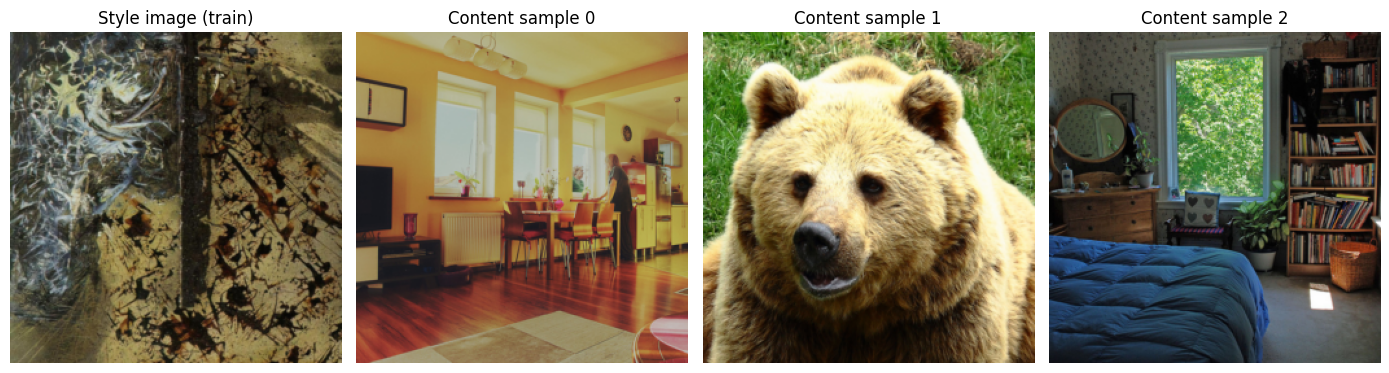

In [ ]:
# Quick visual sanity check
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(tensor_to_pil(style_img[0])); axes[0].set_title("Style image (train)"); axes[0].axis("off")
for i in range(3):
    if len(train_dataset) > 0:
        axes[i + 1].imshow(tensor_to_pil(train_dataset[i]))
        axes[i + 1].set_title(f"Content sample {i}")
    axes[i + 1].axis("off")
plt.tight_layout(); plt.show()


## 2. VGG perceptual loss network
Used for computing content loss and style (Gram-matrix) loss while training the Fast Neural Style Transfer network, and again later as a metric at evaluation time. Standard ImageNet-pretrained VGG16, following Johnson et al. (2016).

In [ ]:
class VGGFeatures(nn.Module):
    LAYER_NAMES = ["relu1_2", "relu2_2", "relu3_3", "relu4_3"]
    LAYER_IDX = {3: "relu1_2", 8: "relu2_2", 15: "relu3_3", 22: "relu4_3"}

    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.slices = vgg[:23]
        for p in self.parameters():
            p.requires_grad = False
        self.eval()

    def forward(self, x):
        x = imagenet_normalize(x)
        out = {}
        h = x
        for i, layer in enumerate(self.slices):
            h = layer(h)
            if i in self.LAYER_IDX:
                out[self.LAYER_IDX[i]] = h
        return out


def gram_matrix(feat):
    b, c, h, w = feat.shape
    feat = feat.view(b, c, h * w)
    gram = torch.bmm(feat, feat.transpose(1, 2)) / (c * h * w)
    return gram


vgg_loss_net = VGGFeatures().to(DEVICE)
print("VGG perceptual loss network ready.")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 229MB/s] 


VGG perceptual loss network ready.


## 3. Model 1 (trained by student): Fast Neural Style Transfer
Feed-forward image transformation network, trained with the perceptual-loss framework of Johnson, Alahi & Fei-Fei (2016). This is the model we actually train end-to-end on the COCO content set for a single style image.

In [ ]:
class ConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride):
        super().__init__()
        self.pad = nn.ReflectionPad2d(kernel_size // 2)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride)

    def forward(self, x):
        return self.conv(self.pad(x))


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvLayer(channels, channels, 3, 1)
        self.in1 = nn.InstanceNorm2d(channels, affine=True)
        self.conv2 = ConvLayer(channels, channels, 3, 1)
        self.in2 = nn.InstanceNorm2d(channels, affine=True)
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.relu(self.in1(self.conv1(x)))
        out = self.in2(self.conv2(out))
        return out + residual


class UpsampleConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride, upsample=2):
        super().__init__()
        self.upsample = upsample
        self.pad = nn.ReflectionPad2d(kernel_size // 2)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride)

    def forward(self, x):
        if self.upsample:
            x = F.interpolate(x, mode="nearest", scale_factor=self.upsample)
        return self.conv(self.pad(x))


class TransformerNet(nn.Module): # Image transformation network from Johnson et al. (2016).
    def __init__(self):
        super().__init__()
        self.conv1 = ConvLayer(3, 32, 9, 1);  self.in1 = nn.InstanceNorm2d(32, affine=True)
        self.conv2 = ConvLayer(32, 64, 3, 2); self.in2 = nn.InstanceNorm2d(64, affine=True)
        self.conv3 = ConvLayer(64, 128, 3, 2); self.in3 = nn.InstanceNorm2d(128, affine=True)
        self.res = nn.Sequential(*[ResidualBlock(128) for _ in range(5)])
        self.up1 = UpsampleConvLayer(128, 64, 3, 1); self.in4 = nn.InstanceNorm2d(64, affine=True)
        self.up2 = UpsampleConvLayer(64, 32, 3, 1);  self.in5 = nn.InstanceNorm2d(32, affine=True)
        self.up3 = ConvLayer(32, 3, 9, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        y = self.relu(self.in1(self.conv1(x)))
        y = self.relu(self.in2(self.conv2(y)))
        y = self.relu(self.in3(self.conv3(y)))
        y = self.res(y)
        y = self.relu(self.in4(self.up1(y)))
        y = self.relu(self.in5(self.up2(y)))
        y = torch.sigmoid(self.up3(y))   # keep output in [0, 1]
        return y


def total_variation(img):
    dh = torch.mean(torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]))
    dw = torch.mean(torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]))
    return dh + dw


In [ ]:
def train_fast_style_transfer(style_img, train_loader, cfg, tag="style"):
    model = TransformerNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

    style_batch = style_img.to(DEVICE).repeat(cfg["batch_size"], 1, 1, 1)
    with torch.no_grad():
        style_feats = vgg_loss_net(style_batch)
        style_grams = {k: gram_matrix(v) for k, v in style_feats.items()}

    history = {"total": [], "content": [], "style": [], "tv": []}
    model.train()
    step = 0
    t0 = time.time()
    for epoch in range(cfg["epochs"]):
        for content in train_loader:
            content = content.to(DEVICE)
            optimizer.zero_grad()

            output = model(content)

            content_feats = vgg_loss_net(content)
            output_feats = vgg_loss_net(output)

            c_loss = cfg["content_weight"] * F.mse_loss(output_feats["relu2_2"], content_feats["relu2_2"])

            s_loss = 0.0
            for key in output_feats:
                g_out = gram_matrix(output_feats[key])
                g_style = style_grams[key][: content.size(0)]
                s_loss = s_loss + F.mse_loss(g_out, g_style)
            s_loss = cfg["style_weight"] * s_loss

            tv_loss = cfg["tv_weight"] * total_variation(output)

            loss = c_loss + s_loss + tv_loss
            loss.backward()
            optimizer.step()

            history["total"].append(loss.item())
            history["content"].append(c_loss.item())
            history["style"].append(s_loss.item())
            history["tv"].append(tv_loss.item())

            if step % cfg["log_every"] == 0:
                elapsed = time.time() - t0
                print(f"[{tag}] epoch {epoch} step {step} "
                      f"total={loss.item():.2f} content={c_loss.item():.2f} "
                      f"style={s_loss.item():.2f} tv={tv_loss.item():.4f} "
                      f"({elapsed:.1f}s elapsed)")
            step += 1

    ckpt_path = CFG["fst_ckpt_dir"] / f"fst_{tag}.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved checkpoint to {ckpt_path}")
    return model, history


In [ ]:
# Train the Fast Neural Style Transfer network on the chosen style.
fst_model, fst_history = train_fast_style_transfer(style_img, train_loader, CFG, tag=CFG["style_name_for_training"])


[expressionism] epoch 0 step 0 total=6227911.00 content=1105589.50 style=5122321.50 tv=0.0000 (0.4s elapsed)
[expressionism] epoch 0 step 200 total=1161681.50 content=786198.69 style=375482.81 tv=0.0000 (18.0s elapsed)
[expressionism] epoch 0 step 400 total=859268.50 content=648509.25 style=210759.25 tv=0.0000 (35.6s elapsed)
[expressionism] epoch 0 step 600 total=791370.88 content=645336.62 style=146034.27 tv=0.0000 (53.4s elapsed)
[expressionism] epoch 0 step 800 total=638002.25 content=504832.28 style=133169.97 tv=0.0000 (71.2s elapsed)
[expressionism] epoch 0 step 1000 total=666871.50 content=546043.19 style=120828.30 tv=0.0000 (89.1s elapsed)
[expressionism] epoch 1 step 1200 total=668577.38 content=497450.16 style=171127.22 tv=0.0000 (107.3s elapsed)
[expressionism] epoch 1 step 1400 total=599882.69 content=463965.59 style=135917.09 tv=0.0000 (125.3s elapsed)
[expressionism] epoch 1 step 1600 total=530328.12 content=425905.72 style=104422.42 tv=0.0000 (143.3s elapsed)
[expression

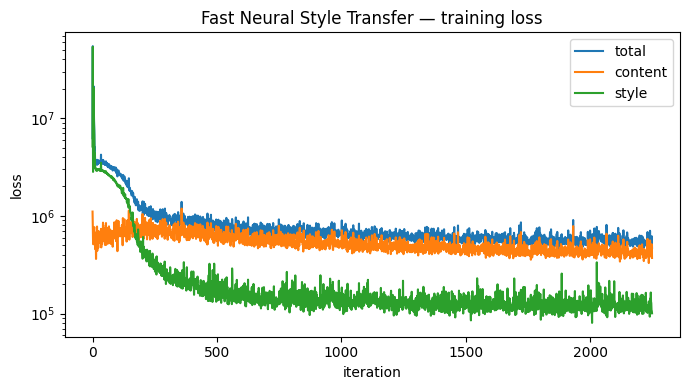

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(fst_history["total"], label="total")
plt.plot(fst_history["content"], label="content")
plt.plot(fst_history["style"], label="style")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.yscale("log")
plt.title("Fast Neural Style Transfer — training loss")
plt.legend(); plt.tight_layout(); plt.show()


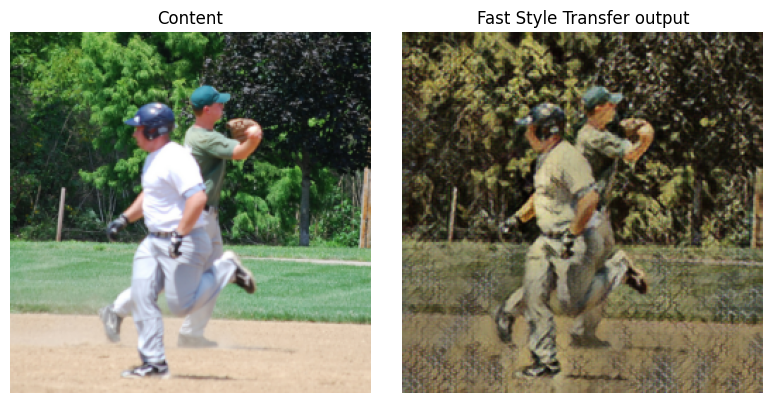

In [ ]:
@torch.no_grad()
def run_fst(model, content_batch):
    model.eval()
    return model(content_batch.to(DEVICE)).clamp(0, 1)

if len(test_dataset) > 0:
    sample = test_dataset[0].unsqueeze(0)
    out = run_fst(fst_model, sample)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(tensor_to_pil(sample[0])); axes[0].set_title("Content"); axes[0].axis("off")
    axes[1].imshow(tensor_to_pil(out[0])); axes[1].set_title("Fast Style Transfer output"); axes[1].axis("off")
    plt.tight_layout(); plt.show()


## 4. Model 2 (existing method): AdaIN
Huang & Belongie, *"Arbitrary Style Transfer in Real-time with Adaptive Instance Normalization"*, ICCV 2017. Encoder = truncated VGG19 (up to relu4_1), decoder = mirrored architecture, trained by the original authors. We load their official pretrained weights (downloaded by `scripts/download_pretrained_weights.py`).

This architecture (`vgg`/`decoder` definitions below) matches the naoto0804/pytorch-AdaIN reference implementation exactly, since we are loading their released weight files — do not change layer order/shapes.

In [ ]:
def build_adain_vgg():
    return nn.Sequential(
        nn.Conv2d(3, 3, (1, 1)),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(3, 64, (3, 3)), nn.ReLU(),      
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(64, 64, (3, 3)), nn.ReLU(),     
        nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(64, 128, (3, 3)), nn.ReLU(),    
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(128, 128, (3, 3)), nn.ReLU(),   
        nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(128, 256, (3, 3)), nn.ReLU(),   
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),   
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),   
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),   
        nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 512, (3, 3)), nn.ReLU(),    
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(512, 512, (3, 3)), nn.ReLU(),   
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(512, 512, (3, 3)), nn.ReLU(),   
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(512, 512, (3, 3)), nn.ReLU(),   
        nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(512, 512, (3, 3)), nn.ReLU(),   
    )

def build_adain_decoder():
    return nn.Sequential(
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(512, 256, (3, 3)), nn.ReLU(),
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 128, (3, 3)), nn.ReLU(),
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(128, 128, (3, 3)), nn.ReLU(),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(128, 64, (3, 3)), nn.ReLU(),
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(64, 64, (3, 3)), nn.ReLU(),
        nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(64, 3, (3, 3)),
    )


def adaptive_instance_norm(content_feat, style_feat, eps=1e-5):
    b, c = content_feat.shape[:2]
    c_mean = content_feat.view(b, c, -1).mean(dim=2).view(b, c, 1, 1)
    c_std = (content_feat.view(b, c, -1).var(dim=2) + eps).sqrt().view(b, c, 1, 1)
    s_mean = style_feat.view(b, c, -1).mean(dim=2).view(b, c, 1, 1)
    s_std = (style_feat.view(b, c, -1).var(dim=2) + eps).sqrt().view(b, c, 1, 1)
    normalized = (content_feat - c_mean) / c_std
    return normalized * s_std + s_mean


class AdaINModel(nn.Module):
    def __init__(self, vgg_weights_path, decoder_weights_path):
        super().__init__()
        vgg_full = build_adain_vgg()
        vgg_full.load_state_dict(torch.load(vgg_weights_path, map_location="cpu"), strict=False)
        self.encoder = nn.Sequential(*list(vgg_full.children())[:31])  # up to relu4_1
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.encoder.eval()

        self.decoder = build_adain_decoder()
        self.decoder.load_state_dict(torch.load(decoder_weights_path, map_location="cpu"))
        self.decoder.eval()

    @torch.no_grad()
    def forward(self, content, style, alpha=1.0):
        content_feat = self.encoder(content)
        style_feat = self.encoder(style)
        t = adaptive_instance_norm(content_feat, style_feat)
        t = alpha * t + (1 - alpha) * content_feat
        return self.decoder(t).clamp(0, 1)


In [ ]:
adain_vgg_path = CFG["adain_weights_dir"] / "vgg_normalised.pth"
adain_decoder_path = CFG["adain_weights_dir"] / "decoder.pth"

adain_model = None
if adain_vgg_path.exists() and adain_decoder_path.exists():
    adain_model = AdaINModel(adain_vgg_path, adain_decoder_path).to(DEVICE)
    print("AdaIN model loaded.")
else:
    print(f"[WARN] AdaIN weights not found under {CFG['adain_weights_dir']}. "
          f"Run scripts/download_pretrained_weights.py first.")


AdaIN model loaded.


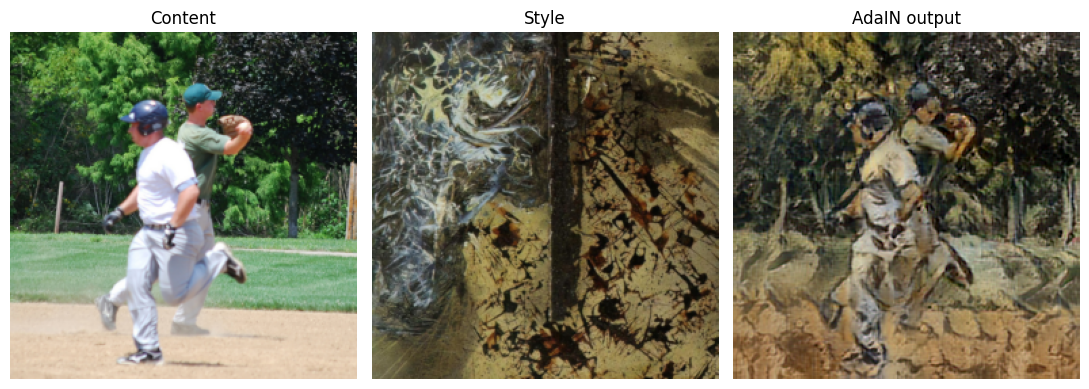

In [ ]:
if adain_model is not None and len(test_dataset) > 0:
    content_sample = test_dataset[0].unsqueeze(0).to(DEVICE)
    style_sample = style_img.to(DEVICE)
    with torch.no_grad():
        adain_out = adain_model(content_sample, style_sample)
    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    axes[0].imshow(tensor_to_pil(content_sample[0])); axes[0].set_title("Content"); axes[0].axis("off")
    axes[1].imshow(tensor_to_pil(style_sample[0])); axes[1].set_title("Style"); axes[1].axis("off")
    axes[2].imshow(tensor_to_pil(adain_out[0])); axes[2].set_title("AdaIN output"); axes[2].axis("off")
    plt.tight_layout(); plt.show()


## 5. Model 3 (existing, recent method): StyTr²
Deng, Tang, Dong, Ma, Pan, Wang & Xu, *"StyTr²: Image Style Transfer with Transformers"*, CVPR 2022. Transformer encoder–decoder based arbitrary style transfer — genuinely recent SOTA. Rather than re-implementing the full transformer architecture (content/style transformer encoders + positional CNN embedding + transformer decoder — non-trivial to reproduce exactly), we use the **official implementation** and their released pretrained weights, which is standard practice when benchmarking against a published method.

In [ ]:
import subprocess

stytr2_repo = CFG["stytr2_repo_dir"]
if not stytr2_repo.exists():
    print("Cloning official StyTr^2 repository...")
    subprocess.run(["git", "clone", "https://github.com/diyiiyiii/StyTR-2.git", str(stytr2_repo)], check=True)
else:
    print("StyTr^2 repo already present at", stytr2_repo)

sys.path.insert(0, str(stytr2_repo))


Cloning official StyTr^2 repository...


Cloning into 'external/StyTR-2'...


In [ ]:
misc_path = CFG["stytr2_repo_dir"] / "util" / "misc.py"
src = misc_path.read_text()
patched = src.replace("float(torchvision.__version__[:3]) < 0.7", "False")
if patched != src:
    misc_path.write_text(patched)
    print("Patched util/misc.py")

for name in list(sys.modules):
    if name == "models" or name.startswith("models.") or name == "util" or name.startswith("util."):
        del sys.modules[name]

stytr2_model = None
try:
    import models.transformer as stytr2_transformer
    import models.StyTR as StyTR

    wdir = CFG["stytr2_weights_dir"]

    vgg = StyTR.vgg
    vgg.load_state_dict(torch.load(wdir / "vgg_normalised.pth", map_location="cpu"))
    vgg = nn.Sequential(*list(vgg.children())[:44])

    decoder = StyTR.decoder
    decoder.load_state_dict(torch.load(wdir / "decoder.pth", map_location="cpu"))

    embedding = StyTR.PatchEmbed()
    embedding.load_state_dict(torch.load(wdir / "vit_embedding.pth", map_location="cpu"))

    transformer_module = stytr2_transformer.Transformer()
    transformer_module.load_state_dict(torch.load(wdir / "transformer.pth", map_location="cpu"))

    stytr2_model = StyTR.StyTrans(vgg, decoder, embedding, transformer_module, None).to(DEVICE)
    stytr2_model.eval()
    print("StyTr^2 model loaded.")
except Exception as e:
    import traceback; traceback.print_exc()
    print(f"[WARN] Could not load StyTr^2 automatically: {e}")

StyTr^2 model loaded.


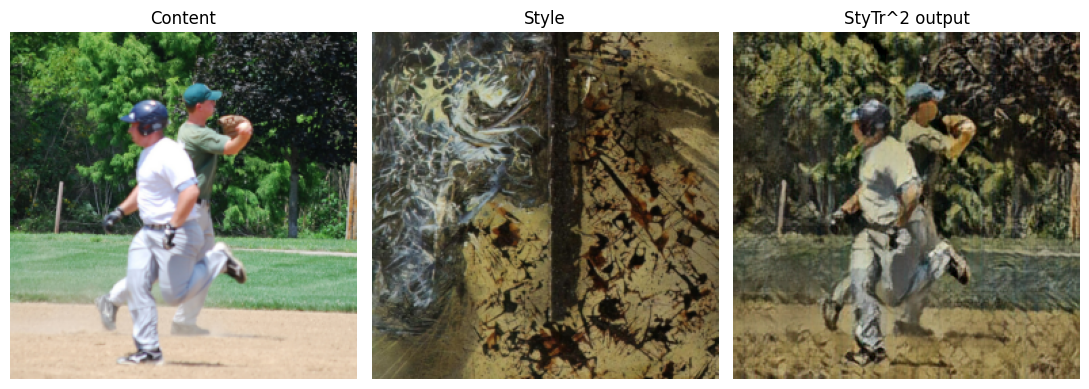

In [ ]:
@torch.no_grad()
def run_stytr2(model, content, style):
    model.eval()
    out = model(content, style)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out.clamp(0, 1)

if stytr2_model is not None and len(test_dataset) > 0:
    content_sample = test_dataset[0].unsqueeze(0).to(DEVICE)
    style_sample = style_img.to(DEVICE)
    try:
        stytr2_out = run_stytr2(stytr2_model, content_sample, style_sample)
        fig, axes = plt.subplots(1, 3, figsize=(11, 4))
        axes[0].imshow(tensor_to_pil(content_sample[0])); axes[0].set_title("Content"); axes[0].axis("off")
        axes[1].imshow(tensor_to_pil(style_sample[0])); axes[1].set_title("Style"); axes[1].axis("off")
        axes[2].imshow(tensor_to_pil(stytr2_out[0])); axes[2].set_title("StyTr^2 output"); axes[2].axis("off")
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"[WARN] StyTr^2 forward pass failed: {e}. See note above about matching the official API.")


## 6. Quantitative evaluation
Three-plus metrics, computed over a held-out set of content images (and the evaluation style images):
1. **Content loss** — perceptual (VGG feature) distance between output and content image (lower = better content preservation).
2. **Style loss** — Gram-matrix distance between output and style image (lower = closer stylization).
3. **SSIM** — structural similarity between output and content image (higher = more structure preserved).
4. **LPIPS** — learned perceptual distance between output and content image (lower = more perceptually similar to content).
5. **Inference time** — seconds per image (efficiency comparison across architectures).

In [ ]:
from skimage.metrics import structural_similarity as ssim_fn
import lpips as lpips_lib

lpips_net = lpips_lib.LPIPS(net="alex").to(DEVICE)
lpips_net.eval()

@torch.no_grad()
def compute_metrics(output, content, style):
    '''output, content, style: (1, 3, H, W) tensors in [0, 1] on DEVICE.'''
    out_feats = vgg_loss_net(output)
    content_feats = vgg_loss_net(content)
    style_feats = vgg_loss_net(style)

    content_loss = F.mse_loss(out_feats["relu2_2"], content_feats["relu2_2"]).item()

    style_loss = 0.0
    for k in out_feats:
        style_loss += F.mse_loss(gram_matrix(out_feats[k]), gram_matrix(style_feats[k])).item()

    out_np = output[0].permute(1, 2, 0).cpu().numpy()
    content_np = content[0].permute(1, 2, 0).cpu().numpy()
    ssim_val = ssim_fn(out_np, content_np, channel_axis=2, data_range=1.0)

    lpips_val = lpips_net(output * 2 - 1, content * 2 - 1).item()  # LPIPS expects [-1, 1]

    return {"content_loss": content_loss, "style_loss": style_loss, "ssim": ssim_val, "lpips": lpips_val}


@torch.no_grad()
def time_inference(fn, *args, n_repeats=5):
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_repeats):
        fn(*args)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / n_repeats


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 221MB/s] 


Loading model from: /root/miniconda3/envs/py3.10/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


In [ ]:
def evaluate_all_models(n_images=None):
    n_images = n_images or CFG["n_eval_content_images"]
    n_images = min(n_images, len(test_dataset))
    style_eval_img = style_img.to(DEVICE)  

    rows = []
    for i in range(n_images):
        content = test_dataset[i].unsqueeze(0).to(DEVICE)

        # Fast Neural Style Transfer (trained)
        t = time_inference(lambda: run_fst(fst_model, content))
        out = run_fst(fst_model, content)
        m = compute_metrics(out, content, style_eval_img)
        rows.append({"model": "Fast-NST (trained)", "image_idx": i, "inference_time_s": t, **m})

        # AdaIN
        if adain_model is not None:
            t = time_inference(lambda: adain_model(content, style_eval_img))
            out = adain_model(content, style_eval_img)
            m = compute_metrics(out, content, style_eval_img)
            rows.append({"model": "AdaIN (2017)", "image_idx": i, "inference_time_s": t, **m})

        # StyTr^2
        if stytr2_model is not None:
            try:
                t = time_inference(lambda: run_stytr2(stytr2_model, content, style_eval_img))
                out = run_stytr2(stytr2_model, content, style_eval_img)
                m = compute_metrics(out, content, style_eval_img)
                rows.append({"model": "StyTr^2 (2022)", "image_idx": i, "inference_time_s": t, **m})
            except Exception as e:
                print(f"[WARN] Skipping StyTr^2 for image {i}: {e}")

    return pd.DataFrame(rows)

results_df = evaluate_all_models()
results_df.head()


,model,image_idx,inference_time_s,content_loss,style_loss,ssim,lpips
0,Fast-NST (trained),0,0.003090,3.667988,0.000009,0.625875,0.362005
1,AdaIN (2017),0,0.006557,7.907064,0.000015,0.198347,0.462932
2,StyTr^2 (2022),0,0.083259,4.675184,0.000019,0.574923,0.383001
3,Fast-NST (trained),1,0.003810,3.711234,0.000014,0.465888,0.659553
4,AdaIN (2017),1,0.006873,6.985198,0.000016,0.185971,0.691474


In [ ]:
summary = results_df.groupby("model")[["content_loss", "style_loss", "ssim", "lpips", "inference_time_s"]].agg(["mean", "std"])
summary


content_loss           style_loss                    ssim  \
                           mean       std       mean           std      mean   
model                                                                          
AdaIN (2017)           8.677104  1.661272   0.000016  8.483112e-07  0.182415   
Fast-NST (trained)     4.282500  0.767480   0.000013  3.563771e-06  0.536831   
StyTr^2 (2022)         5.823643  1.232188   0.000021  2.978506e-06  0.457522   

                                 lpips           inference_time_s            
                         std      mean       std             mean       std  
model                                                                        
AdaIN (2017)        0.031760  0.574005  0.078584         0.006801  0.000111  
Fast-NST (trained)  0.092116  0.454007  0.099386         0.003720  0.000169  
StyTr^2 (2022)      0.077991  0.517518  0.092245         0.084548  0.000545

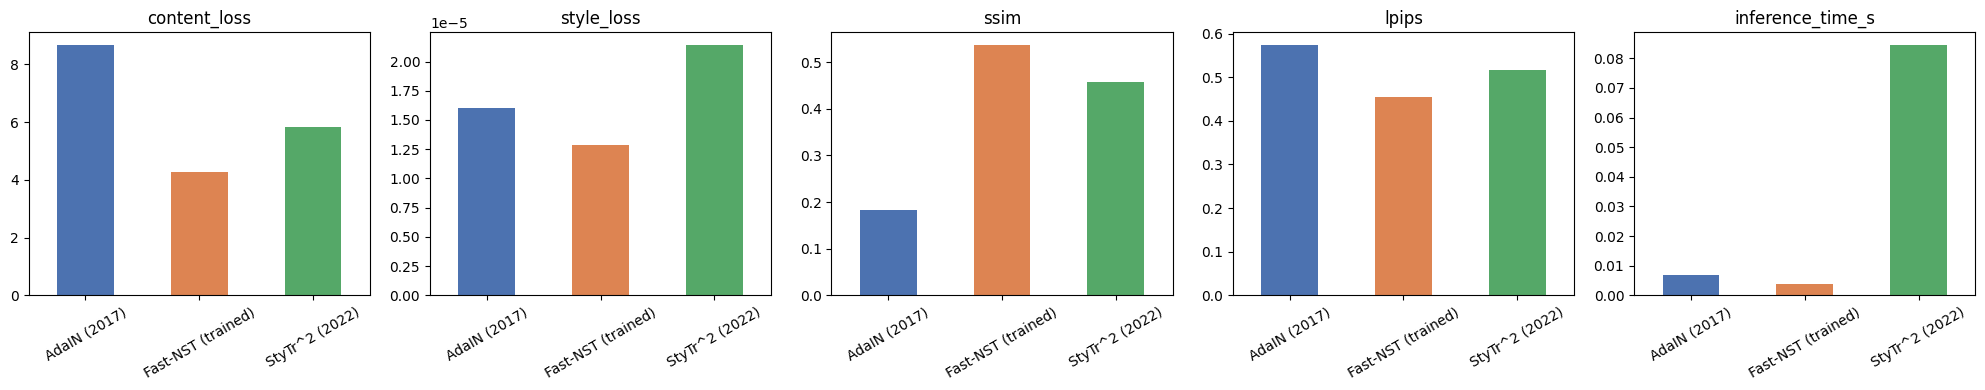

In [ ]:
metrics_to_plot = ["content_loss", "style_loss", "ssim", "lpips", "inference_time_s"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 4))
means = results_df.groupby("model")[metrics_to_plot].mean()
for ax, metric in zip(axes, metrics_to_plot):
    means[metric].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title(metric); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


## 7. Qualitative comparison

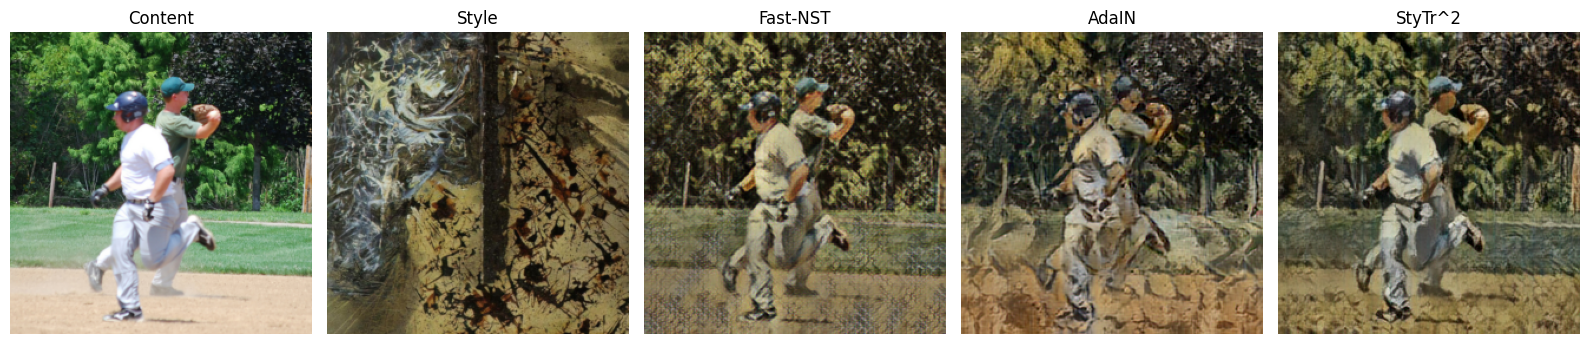

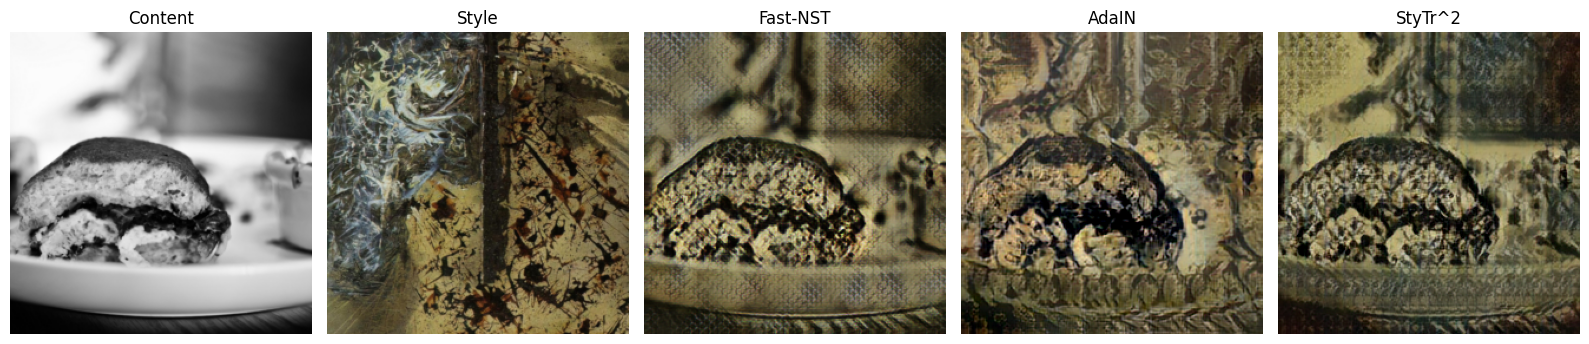

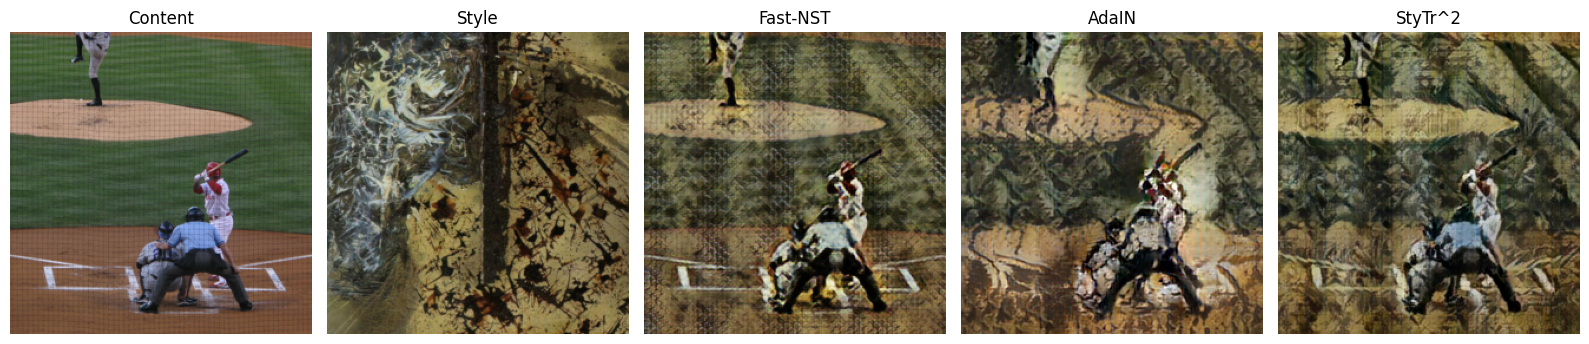

In [ ]:
def qualitative_grid(idx=0, n=1):
    style_eval_img = style_img.to(DEVICE)
    for i in range(idx, idx + n):
        content = test_dataset[i].unsqueeze(0).to(DEVICE)
        imgs = [content[0], style_eval_img[0], run_fst(fst_model, content)[0]]
        titles = ["Content", "Style", "Fast-NST"]
        if adain_model is not None:
            imgs.append(adain_model(content, style_eval_img)[0]); titles.append("AdaIN")
        if stytr2_model is not None:
            try:
                imgs.append(run_stytr2(stytr2_model, content, style_eval_img)[0]); titles.append("StyTr^2")
            except Exception:
                pass
        fig, axes = plt.subplots(1, len(imgs), figsize=(3.2 * len(imgs), 3.5))
        for ax, im, title in zip(axes, imgs, titles):
            ax.imshow(tensor_to_pil(im)); ax.set_title(title); ax.axis("off")
        plt.tight_layout(); plt.show()

if len(test_dataset) > 0:
    qualitative_grid(idx=0, n=3)


## 8. Ablation study
Effect of the content/style loss weight ratio on the Fast Neural Style Transfer network. Each run uses a reduced iteration budget (fewer epochs / a data subset) purely to keep this ablation cheap — bump up `ablation_epochs` if your rented GPU budget allows.

In [ ]:
ablation_style_weights = [1e8, 1e9, 1e10, 1e11]  
ablation_epochs = 1
ablation_subset_size = min(2000, len(train_dataset))

ablation_indices = list(range(ablation_subset_size))
ablation_subset = torch.utils.data.Subset(train_dataset, ablation_indices)
ablation_loader = DataLoader(ablation_subset, batch_size=CFG["batch_size"], shuffle=True, drop_last=True)

ablation_results = []
for sw in ablation_style_weights:
    cfg_ablation = dict(CFG)
    cfg_ablation["style_weight"] = sw
    cfg_ablation["epochs"] = ablation_epochs
    print(f"\\n Ablation run: style_weight={sw:.0e}")
    model_i, hist_i = train_fast_style_transfer(style_img, ablation_loader, cfg_ablation, tag=f"ablation_sw{sw:.0e}")

    # Evaluate final content/style loss on a few test images
    c_losses, s_losses = [], []
    for i in range(min(10, len(test_dataset))):
        content = test_dataset[i].unsqueeze(0).to(DEVICE)
        out = run_fst(model_i, content)
        m = compute_metrics(out, content, style_img.to(DEVICE))
        c_losses.append(m["content_loss"]); s_losses.append(m["style_loss"])
    ablation_results.append({
        "style_weight": sw,
        "content_loss_mean": float(np.mean(c_losses)),
        "style_loss_mean": float(np.mean(s_losses)),
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df

\n=== Ablation run: style_weight=1e+08 ===
[ablation_sw1e+08] epoch 0 step 0 total=1160843.00 content=1115137.25 style=45705.80 tv=0.0000 (0.1s elapsed)
[ablation_sw1e+08] epoch 0 step 200 total=208764.02 content=189764.89 style=18999.12 tv=0.0000 (20.4s elapsed)
[ablation_sw1e+08] epoch 0 step 400 total=239619.41 content=224613.42 style=15005.98 tv=0.0000 (40.7s elapsed)
Saved checkpoint to models/fst/fst_ablation_sw1e+08.pth
\n=== Ablation run: style_weight=1e+09 ===
[ablation_sw1e+09] epoch 0 step 0 total=1210594.25 content=883493.25 style=327100.94 tv=0.0000 (0.1s elapsed)
[ablation_sw1e+09] epoch 0 step 200 total=450834.44 content=339698.66 style=111135.79 tv=0.0000 (20.4s elapsed)
[ablation_sw1e+09] epoch 0 step 400 total=384173.06 content=306722.69 style=77450.39 tv=0.0000 (40.6s elapsed)
Saved checkpoint to models/fst/fst_ablation_sw1e+09.pth
\n=== Ablation run: style_weight=1e+10 ===
[ablation_sw1e+10] epoch 0 step 0 total=6344784.00 content=1150802.25 style=5193982.00 tv=0.00

,style_weight,content_loss_mean,style_loss_mean
0,1.000000e+08,1.609996,0.000159
1,1.000000e+09,2.253566,0.000096
2,1.000000e+10,5.277333,0.000014
3,1.000000e+11,8.497442,0.000006


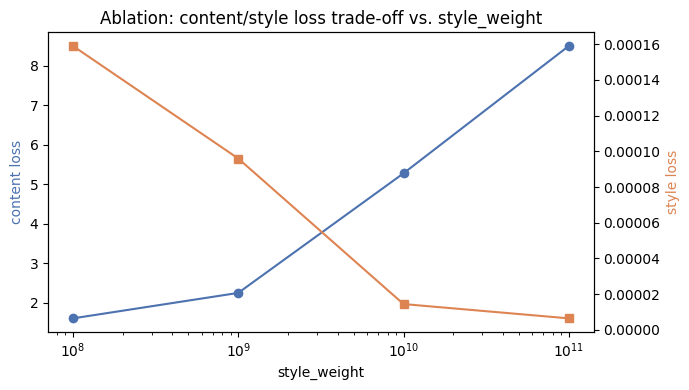

In [ ]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(ablation_df["style_weight"], ablation_df["content_loss_mean"], "o-", color="#4C72B0", label="content loss")
ax1.set_xscale("log"); ax1.set_xlabel("style_weight"); ax1.set_ylabel("content loss", color="#4C72B0")
ax2 = ax1.twinx()
ax2.plot(ablation_df["style_weight"], ablation_df["style_loss_mean"], "s-", color="#DD8452", label="style loss")
ax2.set_ylabel("style loss", color="#DD8452")
plt.title("Ablation: content/style loss trade-off vs. style_weight")
plt.tight_layout(); plt.show()


## 9. Discussion & conclusion

### 9.1 Summary of results
Mean over 30 held-out COCO test images, single style (Expressionism), 256×256 inputs, NVIDIA L4 GPU.

| Model | Content loss ↓ | Style loss ↓ | SSIM ↑ | LPIPS ↓ | Inference time |
|---|---|---|---|---|---|
| **Fast-NST (ours, trained)** | **4.28** | **1.3e-5** | **0.537** | **0.454** | **3.7 ms** |
| AdaIN (2017, pretrained) | 8.68 | 1.6e-5 | 0.182 | 0.574 | 6.8 ms |
| StyTr² (2022, pretrained) | 5.82 | 2.1e-5 | 0.458 | 0.518 | 84.5 ms |

### 9.2 Discussion

**Training.** The Fast Neural Style Transfer network trained stably for 2 epochs (2,250 iterations, about 3.3 minutes on an L4). The total loss fell from about 6.2M to roughly 0.5–0.7M, and the style term dropped by about 98% (5.1M → ~0.1M) within the first ~1,000 iterations. After that the content term kept improving slowly. The loss curve is noisy from iteration to iteration because each batch has different content, but the trend is clearly downward.

**Content preservation.** Fast-NST scored best on all three content-fidelity metrics (content loss, SSIM, LPIPS). StyTr² came second. AdaIN was clearly worst (SSIM 0.18 vs 0.54). This matches the qualitative grid. AdaIN visibly distorts object boundaries and produces ghosting around the players, because it matches only channel-wise mean and variance of the features and has no mechanism to protect spatial structure. StyTr² keeps object shapes intact and gives smooth results, because its attention mechanism relates content and style features globally.

**Style transfer strength.** Style loss favors Fast-NST slightly (1.3e-5 vs 1.6e-5 for AdaIN and 2.1e-5 for StyTr²). However, the gap between Fast-NST and AdaIN is small relative to the variation across images (Fast-NST std ≈ 3.6e-6), so it should not be over-claimed. StyTr²'s style loss is the highest, which fits its visibly subtler, less saturated stylization. Note that SSIM/LPIPS/content loss are measured against the *content* image, so a method that stylizes less will score better on them. These metrics must be read together with the style loss and the images, not alone.

**Efficiency.** Fast-NST was the fastest at 3.7 ms per image. AdaIN was about 1.8× slower and StyTr² about 23× slower than Fast-NST (about 12× slower than AdaIN). This is expected, since StyTr² runs a VGG encoder plus transformer encoder and decoder at test time, while Fast-NST is a single small convolutional network.

**Qualitative observations.** Fast-NST outputs show faint repetitive, grid-like texture artifacts in flat regions (ground, fence). This is a known weakness of feed-forward networks with upsampling. AdaIN shows the strongest texture transfer but with structural distortion. StyTr² gives the cleanest, most content-faithful output but with the weakest color/texture transfer.

### 9.3 Ablation: style weight
Style weight was varied with content weight fixed (1 epoch, 2,000 training images per run):

| style_weight | Content loss ↓ | Style loss ↓ |
|---|---|---|
| 1e8 | 1.61 | 1.6e-4 |
| 1e9 | 2.25 | 9.6e-5 |
| 1e10 | 5.28 | 1.4e-5 |
| 1e11 | 8.50 | 6.0e-6 |

Increasing the style weight monotonically trades content fidelity for style fidelity. Across three orders of magnitude, style loss fell about 26× while content loss rose about 5×. This is the classic style/content trade-off from the perceptual-loss framework. At 1e8 the output is close to the content image with weak stylization, and at 1e11 stylization dominates and content structure degrades. We chose 1e10 for the main experiment as a balance point. (The ablation run at 1e10 has higher content loss than the main run, 5.28 vs 4.28, because the ablation used only 1 epoch on a data subset, which shows that longer training further improves content preservation.)

### 9.4 Limitations and fairness of the comparison
- **Fast-NST is trained on the exact style used for evaluation, while AdaIN and StyTr² are arbitrary-style methods that have never seen it.** Fast-NST's advantage in style loss is therefore partly expected. Its trade-off is that a new network must be trained for every new style, whereas the other two work with any style image at test time.
- Only one style image and 30 test images were used, and training was short (2 epochs, 4,500 images), so results are indicative rather than conclusive.
- StyTr² was trained by its authors at 512 px and evaluated here at 256 px for a common comparison, which may slightly disadvantage it.
- Content/style loss use the same VGG features that Fast-NST was trained on, which may favor it. SSIM and LPIPS (which use independent measures) partly mitigate this.
- Style loss values are small in absolute terms because Gram matrices are normalised by C·H·W; only relative comparisons are meaningful.

### 9.5 Conclusion
We trained a Fast Neural Style Transfer network from scratch and compared it with two pretrained arbitrary-style methods, AdaIN and StyTr², using content loss, style loss, SSIM, LPIPS and inference time. The trained Fast-NST model gave the best content preservation, competitive stylization and the fastest inference, at the cost of being tied to a single style. StyTr² preserved structure better than AdaIN and produced the cleanest images but was by far the slowest. AdaIN offered a fast, flexible middle ground with the weakest structural fidelity. The ablation confirmed the expected style/content trade-off controlled by the loss weight ratio. Future work: evaluate multiple styles, train longer at higher resolution, add a user study or style-specific metrics, and try multi-style or conditional feed-forward networks to remove the one-network-per-style limitation.

## References
1. Johnson, Alahi, Fei-Fei. *Perceptual Losses for Real-Time Style Transfer and Super-Resolution.* ECCV 2016.
2. Gatys, Ecker, Bethge. *Image Style Transfer Using Convolutional Neural Networks.* CVPR 2016.
3. Huang, Belongie. *Arbitrary Style Transfer in Real-time with Adaptive Instance Normalization.* ICCV 2017.
4. Deng, Tang, Dong, Ma, Pan, Wang, Xu. *StyTr²: Image Style Transfer with Transformers.* CVPR 2022.